<h1>1.Business Understanding</h1>
<h2>A.Latar Belakang(Background):</h2>
<p>Industri penerbangan dituntut untuk memiliki standar keselamatan yang sangat tinggi(zero accident). Meskipun kecelakaan pesawat relatif jarang  terjadi dibandingkan moda transportasi lain,dampak yang ditimbulkan(korban jiwa dan kerugian material) sangatlah masif.<p>

<p>Selama ini, investigasi kecelakaan dilakukan secara manual dan pendekatan berdasarkan kasus kasus tertentu oleh lembaga resmi(seperti KNKT atau NTSB). Dengan menggunakan data historis kecelakaan pesawat terbang, pendekatan Machine Learning dapat membantu manusia dalam mengidentifikasi pola tersembunyi, melihat faktor kontributor utama(apakah dari faktor manusia,kegagalan mekanis, atau cuaca), serta memprediksi tingkat keparahan insiden di masa depan. </p>

<h2>B.Tujuan Bisnis</h2>

<ul>
  <li>Mengidentifikasi Faktor Dominan: Mengetahui fitur atau variabel apa yang paling sering memicu terjadinya kecelakaan pesawat (misalnya: fase penerbangan, cuaca, usia pesawat, atau tipe mesin).</li>
  <li>Preventif & Mitigasi Risiko: Memberikan rekomendasi atau insight kepada maskapai, regulator, atau lembaga keselamatan untuk memperketat regulasi pada faktor-faktor yang paling berisiko tinggi.</li>
  <li>Klasifikasi Keparahan: Membangun sistem yang mampu mengklasifikasikan tingkat keparahan kecelakaan (misalnya: Fatal, Serious, Minor, atau No Injury) berdasarkan kondisi-kondisi tertentu saat insiden terjadi.</li>
</ul>


<h1>C. Penilaian Situasi</h1>

<ul>
  <li>Ketersediaan Data: Menggunakan data historis kecelakaan pesawat (seperti dataset dari NTSB, Aviation Safety Network, atau Kaggle).</li>
  <li>Kebutuhan Data: Data harus mencakup informasi cuaca, detail pesawat (manufaktur, model, mesin), informasi penerbangan (fase take-off, cruise, landing), lokasi, serta jumlah korban/kerusakan.</li>
  <li>Kendala (Constraints): Data kecelakaan pesawat sering kali memiliki masalah imbalanced data (kasus fatal biasanya lebih sedikit dibanding insiden minor, atau sebaliknya tergantung penyusunan dataset), serta banyaknya data teks tak terstruktur (kronologi kejadian) yang memerlukan penanganan khusus jika ingin digunakan..</li>
</ul>


<h1></h1>

<h1>D. Tujuan Data Mining (Data Mining Goals)</h1>

<ul>
  <li>
    <strong>Tugas Klasifikasi (Supervised Learning):</strong> 
    Membangun model prediksi untuk mengelompokkan tingkat keparahan kecelakaan (Multi-class Classification) menggunakan tiga algoritma:
    <ul>
      <li><strong>XGBoost:</strong> Sangat kuat dalam akurasi dan menangani pola data yang kompleks secara efisien.</li>
      <li><strong>Support Vector Machine (SVM):</strong> Efektif untuk ruang dimensi tinggi dan mencari hyperplane pemisah terbaik.</li>
    </ul>
  </li>
  <li>
    <strong>Analisis Fitur (Feature Importance):</strong> Mengekstrak bobot variabel dari model (terutama Random Forest dan XGBoost) untuk menentukan faktor yang paling dominan menyebabkan kecelakaan.
  </li>
  <li>
    <strong>Evaluasi Model:</strong> Membandingkan performa ketiga algoritma menggunakan metrik yang tepat 
    (Akurasi, Precision, Recall, dan F1-Score — sangat penting memperhatikan F1-Score karena potensi imbalanced data).
  </li>
</ul>


<h1>E. Rencana Proyek (Project Plan)</h1>

<ul>
  <li>
    <strong>Business Understanding:</strong> Sesi kita saat ini.
  </li>
  <li>
    <strong>Data Understanding:</strong> 
    <ul>
      <li>Eksplorasi data awal (EDA)</li>
      <li>Cek distribusi kelas keparahan</li>
      <li>Cek missing values</li>
    </ul>
  </li>
  <li>
    <strong>Data Preparation:</strong> 
    <ul>
      <li>Cleaning</li>
      <li>Handling missing values</li>
      <li>Encoding variabel kategorikal</li>
      <li>Scaling (terutama untuk SVM)</li>
      <li>Handling imbalanced data (misal dengan SMOTE jika diperlukan)</li>
    </ul>
  </li>
  <li>
    <strong>Modeling:</strong> 
    <ul>
      <li>Melatih algoritma XGBoost dan SVM</li>
      <li>Melakukan hyperparameter tuning</li>
    </ul>
  </li>
  <li>
    <strong>Evaluation:</strong> Membandingkan performa ketiga model dan menganalisis faktor dominan (feature importance).
  </li>
  <li>
    <strong>Deployment:</strong> (Opsional/Sesuai kebutuhan proyek) 
    <ul>
      <li>Pembuatan laporan</li>
      <li>Visualisasi insight untuk stakeholder</li>
      <li>Integrasi ke dashboard (misalnya menggunakan Streamlit)</li>
    </ul>
  </li>
</ul>


In [141]:
# 1. Data Manipulation \& Numerics
import pandas as pd
import numpy as np
# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
# 1. Train-Test Split
from sklearn.model_selection import train_test_split
# 2. Feature Encoding & Preprocessing
from sklearn.preprocessing import (
  OneHotEncoder,
  label_binarize)
from sklearn.compose import ColumnTransformer
# 3. Handling Class Imbalance
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight

In [143]:
# 1. Machine Learning Algorithms
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
# 2. Model Evaluation Metrics & Displays
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    confusion_matrix, 
    f1_score, 
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    roc_auc_score
)
#3.Cross-Validation / Model Selection
from sklearn.model_selection import StratifiedKFold, cross_val_score
# 4. Utilities
import time
#5.Model Interpretability / Explainability (XAI)
import shap
#6.pickle
import pickle

In [144]:
# Load dataset
df = pd.read_csv('dataset_pesawat_terbang/airline_accidents.csv', encoding='ISO-8859-1', low_memory=False)
#Menampilkan 5 baris pertama
df.head(5)

,Event Id,Investigation Type,Accident Number,Event Date,Location,Country,Latitude,Longitude,Airport Code,Airport Name,...,Purpose of Flight,Air Carrier,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Weather Condition,Broad Phase of Flight,Report Publication Date,Unnamed: 30
0,20080125X00106,Accident,SEA08CA056,12/31/2007,"Santa Ana, CA",United States,33.675556,-117.868056,SNA,John Wayne - Orange County,...,Instructional,,,,,2,VMC,LANDING,02/28/2008,
1,20080206X00141,Accident,CHI08WA075,12/31/2007,"Guernsey, United Kingdom",United Kingdom,49.435000,-2.600278,,,...,Unknown,,,,,1,,,02/06/2008,
2,20080129X00122,Accident,CHI08CA057,12/30/2007,"Alexandria, MN",United States,45.866111,-95.394444,AXN,Chandler Field Airport,...,Personal,,,,,1,VMC,TAKEOFF,02/28/2008,
3,20080114X00045,Accident,LAX08FA043,12/30/2007,"Paso Robles, CA",United States,35.542222,-120.522778,PRB,Paso Robles Airport,...,Personal,,1,,,,VMC,MANEUVERING,06/20/2014,
4,20080109X00032,Accident,NYC08FA071,12/30/2007,"Cherokee, AL",United States,34.688611,-87.920000,,,...,Other Work Use,,3,0,0,0,VMC,MANEUVERING,01/15/2009,


In [145]:
df.tail(5)

,Event Id,Investigation Type,Accident Number,Event Date,Location,Country,Latitude,Longitude,Airport Code,Airport Name,...,Purpose of Flight,Air Carrier,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Weather Condition,Broad Phase of Flight,Report Publication Date,Unnamed: 30
150954,24237,,NYC65I0127,,"BRADFORD, PA",United States,,,,,...,,,0,0,0,0,,,,
150955,24243,,LAX78DUJ68,,"WINSLOW, AZ",United States,,,,,...,,,0,0,0,0,,,,
150956,24242,,MIA74DLD77,,"SARASOTA, FL",United States,,,,,...,,,0,0,0,0,,,,
150957,24239,,LAX68F0032,,"SCOTTSDALE, AZ",United States,,,,,...,,,0,0,0,0,,,,
150958,24240,,OAK69A0051,,"LAKEPORT, CA",United States,,,,,...,,,0,0,0,0,,,,


In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150959 entries, 0 to 150958
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Event Id                 150959 non-null  str  
 1   Investigation Type       150959 non-null  str  
 2   Accident Number          150959 non-null  str  
 3   Event Date               150959 non-null  str  
 4   Location                 150959 non-null  str  
 5   Country                  150959 non-null  str  
 6   Latitude                 150959 non-null  str  
 7   Longitude                150959 non-null  str  
 8   Airport Code             150959 non-null  str  
 9   Airport Name             150959 non-null  str  
 10  Injury Severity          150959 non-null  str  
 11  Aircraft Damage          150959 non-null  str  
 12  Aircraft Category        150959 non-null  str  
 13  Registration Number      150959 non-null  str  
 14  Make                     150959 non-null  str  

In [147]:
df.describe()

,Event Id,Investigation Type,Accident Number,Event Date,Location,Country,Latitude,Longitude,Airport Code,Airport Name,...,Purpose of Flight,Air Carrier,Total Fatal Injuries,Total Serious Injuries,Total Minor Injuries,Total Uninjured,Weather Condition,Broad Phase of Flight,Report Publication Date,Unnamed: 30
count,150959,150959,150959,150959,150959,150959,150959,150959,150959,150959,...,150959,150959,150959,150959,150959,150959,150959,150959,150959,150959
unique,150047,3,143310,16138,33888,168,8868,9268,7881,18236,...,23,2317,109,37,58,344,4,13,2418,1
top,20001212X19172,,Unknown,10/02/1966,"ANCHORAGE, AK",United States,,,,,...,,,0,0,0,0,,,,
freq,3,87046,6031,41,828,147351,138985,138995,116096,113581,...,88765,147848,69035,76874,74262,53398,87554,89235,99786,150959


In [148]:
df.shape

(150959, 31)

In [149]:
# Hilangkan spasi di awal dan akhir teks pada semua kolom kategorikal
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Ubah string kosong, 'nan', atau 'None' menjadi NaN asli Python
df.replace(['', 'nan', 'NaN', 'None'], np.nan, inplace=True)
print("Pembersihan spasi gaib selesai dilakukan di awal.")

C:\Users\Ghally\AppData\Local\Temp\ipykernel_41188\3583597633.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Pembersihan spasi gaib selesai dilakukan di awal.


In [150]:
# 1. Memeriksa missing value asli setelah spasi dihilangkan
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
df_missing = pd.DataFrame({'Total Missing': missing_data, 'Percentage(%)': missing_percent})
print("--- MISSING VALUES YANG SEBENARNYA ---")
print(df_missing[df_missing['Total Missing'] > 0].sort_values(by='Percentage(%)', ascending=False))

# 2. Memeriksa data duplikat
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")

--- MISSING VALUES YANG SEBENARNYA ---
                         Total Missing  Percentage(%)
Unnamed: 30                     150959     100.000000
Air Carrier                     147848      97.939176
Aircraft Category               143206      94.864168
Schedule                        141046      93.433316
Longitude                       138995      92.074669
Latitude                        138985      92.068045
Airport Code                    116096      76.905650
Airport Name                    113616      75.262820
Report Publication Date          99786      66.101392
Number of Engines                89594      59.349890
Broad Phase of Flight            89235      59.112077
Purpose of Flight                88765      58.800734
Aircraft Damage                  88691      58.751714
Engine Type                      88498      58.623865
Weather Condition                87554      57.998529
Investigation Type               87046      57.662014
FAR Description                  56154     

In [151]:
# 1. Fungsi pembersihan target yang aman (case-insensitive)
def clean_injury_severity(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).lower().strip()
    if 'fatal' in val and 'non' not in val:
        return 'Fatal'
    elif 'non' in val and 'fatal' in val:
        return 'Non-Fatal'
    elif 'incident' in val:
        return 'Incident'
    else:
        return 'Other'

df['Injury_Severity_Clean'] = df['Injury Severity'].apply(clean_injury_severity)
print("✅ Pembersihan dan pemetaan kolom target berhasil dilakukan!")

✅ Pembersihan dan pemetaan kolom target berhasil dilakukan!


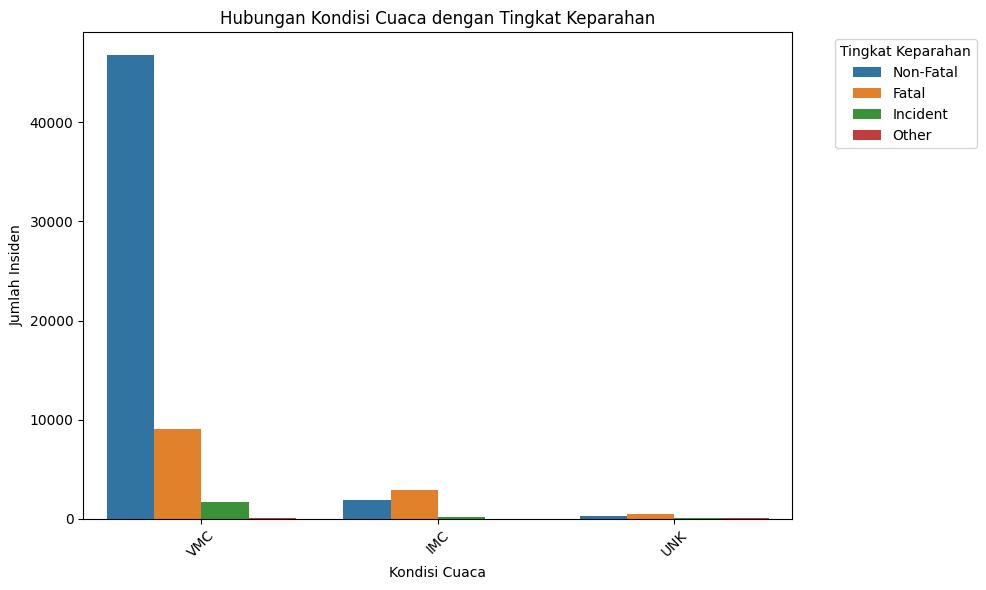

In [152]:
# 2. Visualisasi Hubungan Kondisi Cuaca dengan Tingkat Keparahan
plt.figure(figsize=(10, 6))
top_weather = df['Weather Condition'].value_counts().iloc[:5].index

sns.countplot(data=df[df['Weather Condition'].isin(top_weather)], 
              x='Weather Condition', hue='Injury_Severity_Clean', order=top_weather)

plt.title('Hubungan Kondisi Cuaca dengan Tingkat Keparahan')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Insiden')
plt.xticks(rotation=45)
plt.legend(title='Tingkat Keparahan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

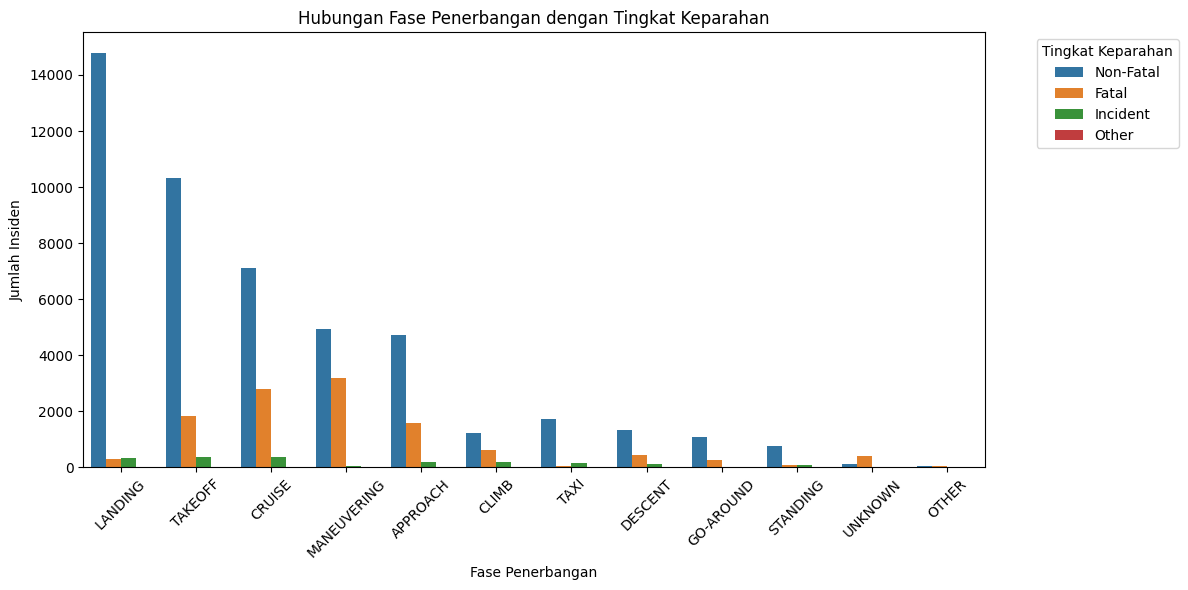

In [153]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Broad Phase of Flight', hue='Injury_Severity_Clean',
              order=df['Broad Phase of Flight'].value_counts().index)

plt.title('Hubungan Fase Penerbangan dengan Tingkat Keparahan')
plt.xlabel('Fase Penerbangan')
plt.ylabel('Jumlah Insiden')
plt.xticks(rotation=45)
plt.legend(title='Tingkat Keparahan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<ul>
  <li>
    <strong>Label Encoding (Target):</strong> 
    Terapkan pada variabel <code>Injury_Severity_Clean</code> agar kelasnya berubah menjadi angka diskrit (misal: 0, 1, 2).
  </li>
  <li>
    <strong>One-Hot Encoding (Fitur Kategorikal):</strong> 
    Gunakan <code>pd.get_dummies</code> pada fitur kategorikal lainnya agar tidak ada asumsi tingkatan/jarak antar kategori teks.
  </li>
</ul>


In [154]:
# 1. Seleksi fitur & Filter 3 kelas utama
features = ['Weather Condition', 'Broad Phase of Flight', 'Aircraft Damage', 'Number of Engines', 'Engine Type', 'Injury_Severity_Clean']
df_model = df[features].copy()
df_model = df_model[df_model['Injury_Severity_Clean'].isin(['Fatal', 'Non-Fatal', 'Incident'])]

# 2. Handling Missing Value Kategorikal
# Khusus Weather Condition: Imputasi 'Unknown'/kosong ke 'VMC' (Visual Meteorological Conditions)
df_model['Weather Condition'] = df_model['Weather Condition'].replace(['Unknown', 'UNK', 'nan', '', np.nan], 'VMC')

# Kolom kategorikal lainnya tetap diisi 'Unknown'
kategorikal_cols = ['Weather Condition', 'Broad Phase of Flight', 'Aircraft Damage', 'Engine Type']
for col in ['Broad Phase of Flight', 'Aircraft Damage', 'Engine Type']:
    df_model[col] = df_model[col].fillna('Unknown')

# 3. Handling Missing Value Numerik
df_model['Number of Engines'] = pd.to_numeric(df_model['Number of Engines'], errors='coerce')

print("✅ Tahap Pembersihan Data & Imputasi Selesai!")

✅ Tahap Pembersihan Data & Imputasi Selesai!


In [155]:
# 4. Pisahkan Fitur (X) dan Target (y)
X = df_model.drop(columns=['Injury_Severity_Clean'])
y = df_model['Injury_Severity_Clean']

# Mapping Target
target_map = {'Incident': 0, 'Non-Fatal': 1, 'Fatal': 2}
y_encoded = y.map(target_map)

# 5. TRAIN-TEST SPLIT DULU (Mencegah Data Leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Imputasi modus pada Number of Engines berdasarkan data TRAIN saja
modus_engines = X_train_raw['Number of Engines'].mode()[0]
X_train_raw['Number of Engines'] = X_train_raw['Number of Engines'].fillna(modus_engines).astype(int)
X_test_raw['Number of Engines'] = X_test_raw['Number of Engines'].fillna(modus_engines).astype(int)

# 6. Fit Encoder HANYA pada X_train_raw
encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), kategorikal_cols)
    ],
    remainder='passthrough'
)

# Fit & Transform pada Training, hanya Transform pada Testing
X_train_array = encoder.fit_transform(X_train_raw)
X_test_array = encoder.transform(X_test_raw)

# Buat DataFrame
feature_names = encoder.get_feature_names_out()
X_train = pd.DataFrame(X_train_array, columns=feature_names)
X_test = pd.DataFrame(X_test_array, columns=feature_names)

print("✅ Preprocessing & Encoding Selesai Tanpa Data Leakage!")

✅ Preprocessing & Encoding Selesai Tanpa Data Leakage!


In [156]:
# Cek jumlah data per kelas
print(y.value_counts())
print("\nPersentase per kelas:")
print(y.value_counts(normalize=True) * 100)

Injury_Severity_Clean
Non-Fatal    122067
Fatal         25146
Incident       3650
Name: count, dtype: int64

Persentase per kelas:
Injury_Severity_Clean
Non-Fatal    80.912484
Fatal        16.668103
Incident      2.419414
Name: proportion, dtype: float64


In [157]:
# 1. Resampling Data Training Menggunakan SMOTE
print("--- Memulai Proses SMOTE ---")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Menghitung bobot agar kelas minoritas mendapatkan perhatian lebih dari model XGBoost
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_resampled)

--- Memulai Proses SMOTE ---


In [158]:
# 2. Inisialisasi Model
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1, tree_method='hist')
# 3. Training XGBoost dengan Sample Weight
print("\n--- Memulai Training XGBoost ---")
start_time = time.time()
xgb_model.fit(X_train_resampled, y_train_resampled, sample_weight=sample_weights)
print(f"XGBoost selesai dalam: {time.time() - start_time:.2f} detik\n")

# 4. Training SVM
base_svm = LinearSVC(random_state=42, max_iter=2000, dual=False, class_weight='balanced')
svm_model = CalibratedClassifierCV(estimator=base_svm)
print("--- Memulai Training SVM ---")
start_time = time.time()
svm_model.fit(X_train_resampled, y_train_resampled)
print(f"SVM selesai dalam: {time.time() - start_time:.2f} detik\n")

print("--- SEMUA MODEL BERHASIL DILATIH! ---")


--- Memulai Training XGBoost ---
XGBoost selesai dalam: 1.88 detik

--- Memulai Training SVM ---
SVM selesai dalam: 4.60 detik

--- SEMUA MODEL BERHASIL DILATIH! ---


In [159]:
# Menggunakan StratifiedKFold agar proporsi kelas terjaga di setiap fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definisikan model dalam dictionary
models = {
    'XGBoost': xgb_model,
    'SVM': svm_model
}

# Evaluasi cross-validation perbandingan model
print("--- PERBANDINGAN CROSS-VALIDATION (F1-Macro) ---")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

--- PERBANDINGAN CROSS-VALIDATION (F1-Macro) ---
XGBoost: 0.6472 (+/- 0.0014)
SVM: 0.6413 (+/- 0.0016)


In [160]:
# Fungsi helper untuk menghitung AUC
def get_auc_score(model, X_test, y_test):
    # Mengambil probabilitas
    y_proba = model.predict_proba(X_test)
    # Menghitung AUC dengan multi_class='ovr' (One-vs-Rest)
    return roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

auc_xgb = get_auc_score(xgb_model, X_test, y_test)
auc_svm = get_auc_score(svm_model, X_test, y_test)

print(f"\n--- PERBANDINGAN ROC-AUC ---")
print(f"XGBoost ROC-AUC: {auc_xgb:.4f}")
print(f"SVM ROC-AUC     : {auc_svm:.4f}")


--- PERBANDINGAN ROC-AUC ---
XGBoost ROC-AUC: 0.8012
SVM ROC-AUC     : 0.7989


In [161]:
summary_metrics = []

# =========================================================================
# 1. KELOMPOK EVALUASI MODEL XGBOOST
# =========================================================================
print("================ HASIL EVALUASI MODEL XGBOOST ================")

# Prediksi
y_pred_xgb = xgb_model.predict(X_test)

# Hitung Metrik Evaluasi
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')

# Simpan Metrik XGBoost
summary_metrics.append({
    'Model': 'XGBoost', 
    'Accuracy (%)': round(acc_xgb * 100, 2), 
    'F1-Score Macro (%)': round(f1_macro_xgb * 100, 2)
})

# Cetak Hasil XGBoost
print(f"Akurasi Keseluruhan : {acc_xgb * 100:.2f}%")
print(f"F1-Score (Macro)    : {f1_macro_xgb * 100:.2f}%")
print("\nLaporan Klasifikasi Detail (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['Incident', 'Non-Fatal', 'Fatal']))


# =========================================================================
# 2. KELOMPOK EVALUASI MODEL SVM
# =========================================================================
print("\n================ HASIL EVALUASI MODEL SVM ================")

# Prediksi
y_pred_svm = svm_model.predict(X_test)

# Hitung Metrik Evaluasi
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_macro_svm = f1_score(y_test, y_pred_svm, average='macro')

# Simpan Metrik SVM
summary_metrics.append({
    'Model': 'SVM', 
    'Accuracy (%)': round(acc_svm * 100, 2), 
    'F1-Score Macro (%)': round(f1_macro_svm * 100, 2)
})

# Cetak Hasil SVM
print(f"Akurasi Keseluruhan : {acc_svm * 100:.2f}%")
print(f"F1-Score (Macro)    : {f1_macro_svm * 100:.2f}%")
print("\nLaporan Klasifikasi Detail (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=['Incident', 'Non-Fatal', 'Fatal']))


# =========================================================================
# 3. RINGKASAN PERBANDINGAN MODEL
# =========================================================================
df_summary = pd.DataFrame(summary_metrics)
print("\n================ RINGKASAN PERBANDINGAN MODEL ================")
print(df_summary)

================ HASIL EVALUASI MODEL XGBOOST ================
Akurasi Keseluruhan : 84.55%
F1-Score (Macro)    : 66.28%

Laporan Klasifikasi Detail (XGBoost):
              precision    recall  f1-score   support

    Incident       0.59      0.56      0.57       730
   Non-Fatal       0.88      0.94      0.91     24414
       Fatal       0.64      0.42      0.51      5029

    accuracy                           0.85     30173
   macro avg       0.70      0.64      0.66     30173
weighted avg       0.83      0.85      0.83     30173


================ HASIL EVALUASI MODEL SVM ================
Akurasi Keseluruhan : 84.84%
F1-Score (Macro)    : 67.03%

Laporan Klasifikasi Detail (SVM):
              precision    recall  f1-score   support

    Incident       0.63      0.56      0.59       730
   Non-Fatal       0.88      0.95      0.91     24414
       Fatal       0.65      0.41      0.51      5029

    accuracy                           0.85     30173
   macro avg       0.72      0.64 

In [162]:
print("--- FAKTOR DOMINAN BERDASARKAN XGBOOST ---")
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

print("5 Faktor Paling Dominan Mempengaruhi Fatalitas:")
for i in range(5):
    print(f"{i+1}. {X_train.columns[indices_xgb[i]]} (Skor: {importances_xgb[indices_xgb[i]]:.4f})")

--- FAKTOR DOMINAN BERDASARKAN XGBOOST ---
5 Faktor Paling Dominan Mempengaruhi Fatalitas:
1. cat__Aircraft Damage_Destroyed (Skor: 0.1890)
2. cat__Aircraft Damage_Minor (Skor: 0.1879)
3. cat__Broad Phase of Flight_Unknown (Skor: 0.1863)
4. cat__Aircraft Damage_Unknown (Skor: 0.1411)
5. cat__Aircraft Damage_Substantial (Skor: 0.1375)


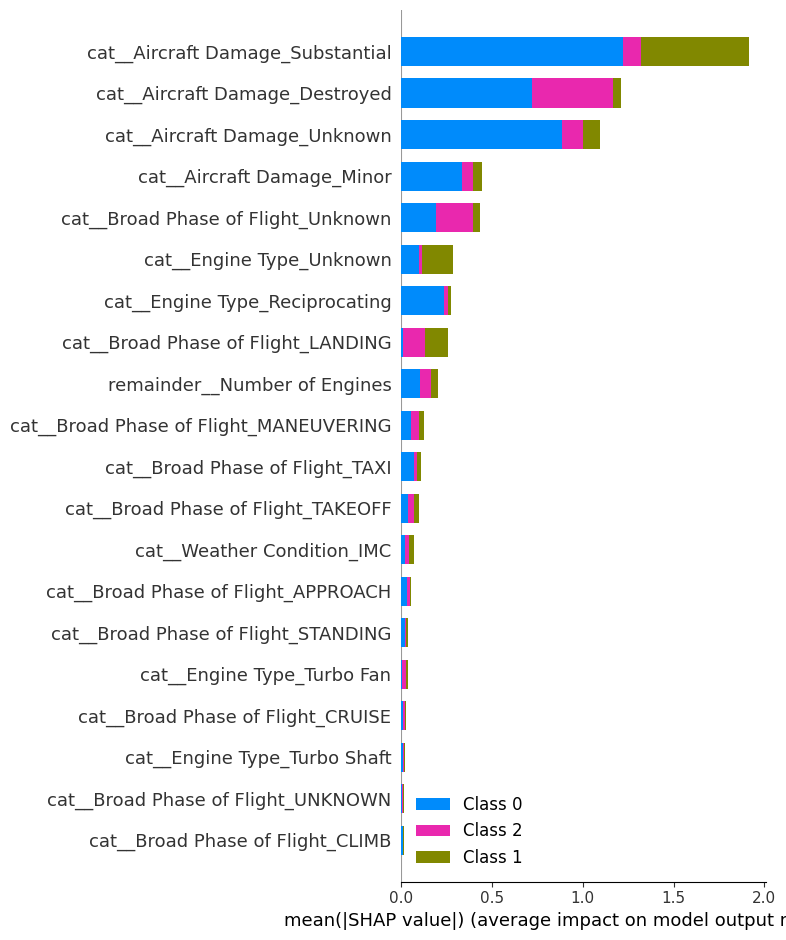

In [163]:
# Membuat objek TreeExplainer untuk model XGBoost (ambil sampel data agar proses cepat)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:1000]) 

# Plot Summary SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:1000], plot_type="bar")


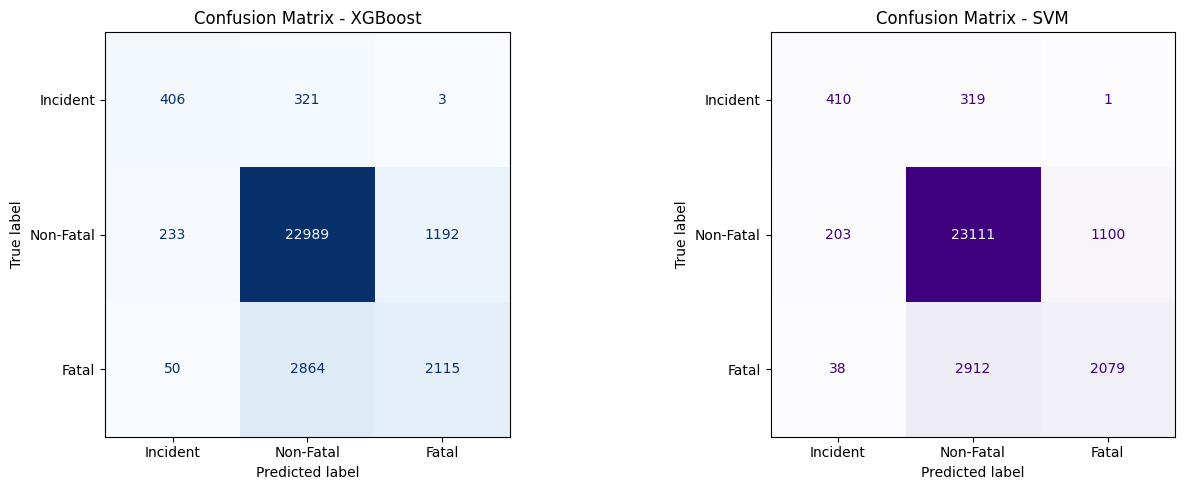

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_labels = ['Incident', 'Non-Fatal', 'Fatal']

# 1. Confusion Matrix XGBoost
y_pred_xgb = xgb_model.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=target_labels)
disp_xgb.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix - XGBoost')
axes[0].grid(False)

# 2. Confusion Matrix SVM
y_pred_svm = svm_model.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=target_labels)
disp_svm.plot(ax=axes[1], cmap='Purples', values_format='d', colorbar=False)
axes[1].set_title('Confusion Matrix - SVM')
axes[1].grid(False)

plt.tight_layout()
plt.show()

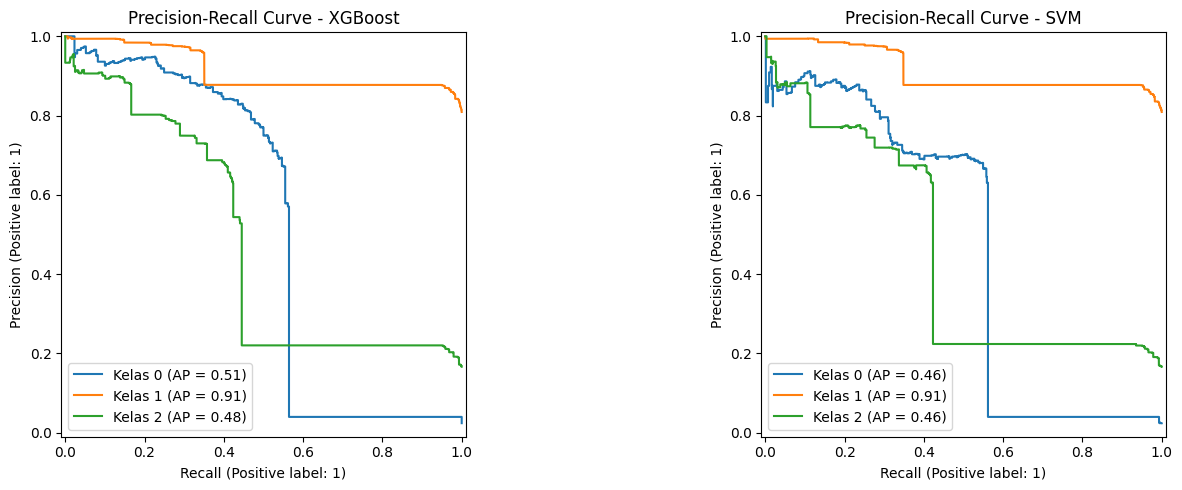

In [165]:
# Binarize labels untuk PR Curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for i, model in enumerate([xgb_model, svm_model]):
    name = 'XGBoost' if i == 0 else 'SVM'
    y_score = model.predict_proba(X_test)
    
    # Plot PR Curve per kelas
    for c in range(n_classes):
        PrecisionRecallDisplay.from_predictions(y_test_bin[:, c], y_score[:, c], ax=ax[i], name=f'Kelas {c}')
    ax[i].set_title(f'Precision-Recall Curve - {name}')

plt.tight_layout()
plt.show()

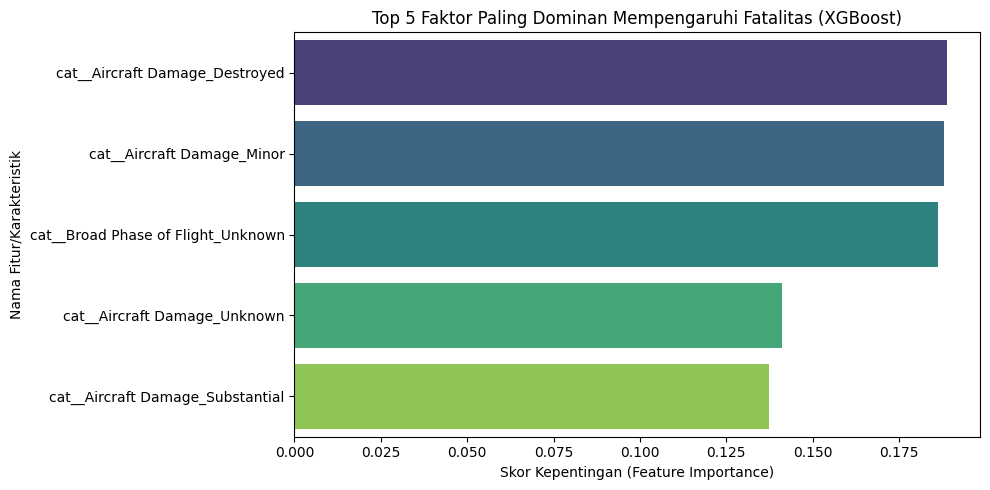

In [166]:
plt.figure(figsize=(10, 5))

# Mengambil top 5 fitur dari XGBoost
top_features_xgb = [X_train.columns[indices_xgb[i]] for i in range(5)]
top_scores_xgb = [importances_xgb[indices_xgb[i]] for i in range(5)]

# Plot grafik batang
sns.barplot(
    x=top_scores_xgb, 
    y=top_features_xgb, 
    hue=top_features_xgb, 
    palette='viridis', 
    legend=False
)

plt.title('Top 5 Faktor Paling Dominan Mempengaruhi Fatalitas (XGBoost)')
plt.xlabel('Skor Kepentingan (Feature Importance)')
plt.ylabel('Nama Fitur/Karakteristik')
plt.tight_layout()
plt.show()


--- FAKTOR DOMINAN BERDASARKAN SVM ---
5 Faktor Paling Dominan Menurut SVM:
1. cat__Aircraft Damage_Minor (Skor Koefisien: 1.0837)
2. cat__Aircraft Damage_Destroyed (Skor Koefisien: 0.9130)
3. cat__Aircraft Damage_Substantial (Skor Koefisien: 0.6366)
4. cat__Broad Phase of Flight_UNKNOWN (Skor Koefisien: 0.4682)
5. cat__Broad Phase of Flight_Unknown (Skor Koefisien: 0.4546)


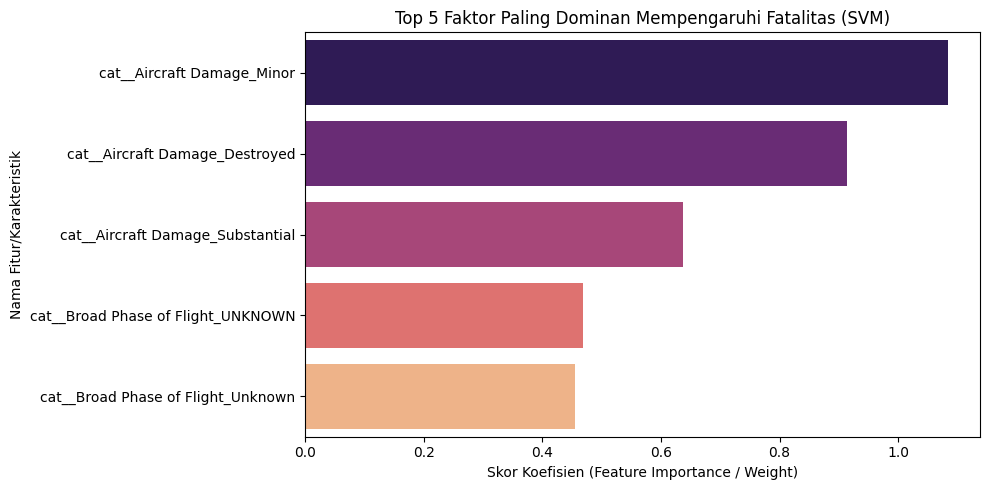

In [168]:
# Mengambil koefisien dari semua fold estimator di dalam CalibratedClassifierCV
all_coefs = [clf.estimator.coef_ for clf in svm_model.calibrated_classifiers_]

# Merata-ratakan nilai absolut koefisien lintas fold dan lintas kelas (karena multikelas)
svm_weights = np.mean([np.abs(coef) for coef in all_coefs], axis=(0, 1))
indices_svm = np.argsort(svm_weights)[::-1]

print("\n--- FAKTOR DOMINAN BERDASARKAN SVM ---")
print("5 Faktor Paling Dominan Menurut SVM:")
for i in range(5):
    print(f"{i+1}. {X_train.columns[indices_svm[i]]} (Skor Koefisien: {svm_weights[indices_svm[i]]:.4f})")

# Visualisasi Top 5 Fitur SVM
plt.figure(figsize=(10, 5))
top_features_svm = [X_train.columns[indices_svm[i]] for i in range(5)]
top_scores_svm = [svm_weights[indices_svm[i]] for i in range(5)]

sns.barplot(
    x=top_scores_svm, 
    y=top_features_svm, 
    hue=top_features_svm, 
    palette='magma', 
    legend=False
)

plt.title('Top 5 Faktor Paling Dominan Mempengaruhi Fatalitas (SVM)')
plt.xlabel('Skor Koefisien (Feature Importance / Weight)')
plt.ylabel('Nama Fitur/Karakteristik')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Ekspor Model XGBoost
with open("model_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# 2. Ekspor Model SVM
with open("model_svm.pkl", "wb") as f:
    pickle.dump(svm_model, f)

# 3. Ekspor Encoder
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("✅ MODEL XGBOOST, SVM, DAN ENCODER BERHASIL DIEKSPOR SINKRON!")

✅ MODEL XGBOOST, SVM, DAN ENCODER BERHASIL DIEKSPOR SINKRON!


In [ ]:
print("Jumlah baris data training:", X_train.shape[0])
print("Jumlah fitur setelah One-Hot Encoding:", X_train.shape[1])

Jumlah baris data training: 120690
Jumlah fitur setelah One-Hot Encoding: 27
